# Истражувачка анализа на податоците (EDA)
Основна анализа на цени, PV производство и временски услови за сите 6 земји, пред feature engineering и моделирање.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

COUNTRIES = ["spain", "greece", "netherlands", "poland", "sweden", "germany"]

data = {c: pd.read_csv(f"../data/processed/fe/{c}_features.csv") for c in COUNTRIES}
for c in COUNTRIES:
    data[c]["datetime"] = pd.to_datetime(data[c]["datetime"])
print("Countries:", list(data.keys()))
print("Total rows", len(data["spain"]))

Countries: ['spain', 'greece', 'netherlands', 'poland', 'sweden', 'germany']
Total rows 34872


## 1. Основни статистики по земја

In [10]:
rows = []
for c in COUNTRIES:
    df = data[c]
    rows.append({
        "country": c,
        "price_mean": df["Price (EUR/MWhe)"].mean(),
        "price_std": df["Price (EUR/MWhe)"].std(),
        "price_neg_pct": (df["Price (EUR/MWhe)"] < 0).mean() * 100,
        "prod_mean": df["solar_generation_MW"].mean(),
        "prod_max": df["solar_generation_MW"].max(),
    })
stats_df = pd.DataFrame(rows).round(1)
stats_df

,country,price_mean,price_std,price_neg_pct,prod_mean,prod_max
0,spain,95.4,67.2,2.3,4907.8,23999.0
1,greece,150.7,107.4,0.4,1080.3,6816.0
2,netherlands,125.3,103.7,4.1,58.4,427.7
3,poland,119.8,63.1,1.6,1693.5,13682.3
4,sweden,62.4,73.5,3.8,104.0,1200.3
5,germany,124.7,105.0,3.3,7146.7,52466.2


## 2. Дистрибуција на цените по земја

/var/folders/l4/6g_95z_n3vd3lqzhhrv9ngs80000gn/T/ipykernel_53384/469775476.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data[c]["Price (EUR/MWhe)"] for c in COUNTRIES], labels=[c.capitalize() for c in COUNTRIES], showfliers=False)


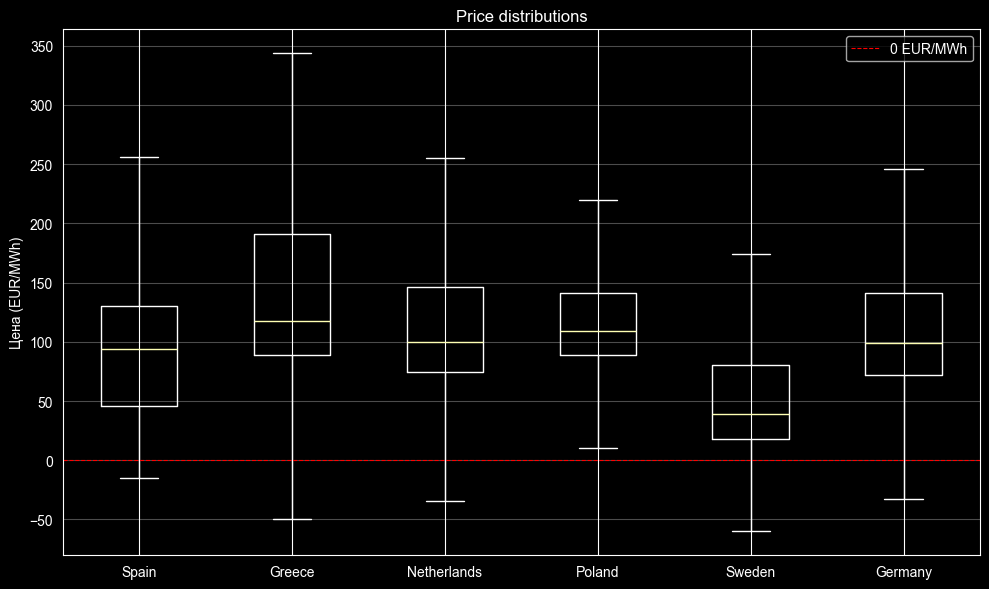

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot([data[c]["Price (EUR/MWhe)"] for c in COUNTRIES], labels=[c.capitalize() for c in COUNTRIES], showfliers=False)
ax.axhline(0, color="red", linestyle="--", linewidth=0.8, label="0 EUR/MWh")
ax.set_ylabel("Цена (EUR/MWh)")
ax.set_title("Price distributions")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../results/eda/price_distribution.png", dpi=150)
plt.show()

## 3. Дневен образец на PV производство (прва недела од test период)

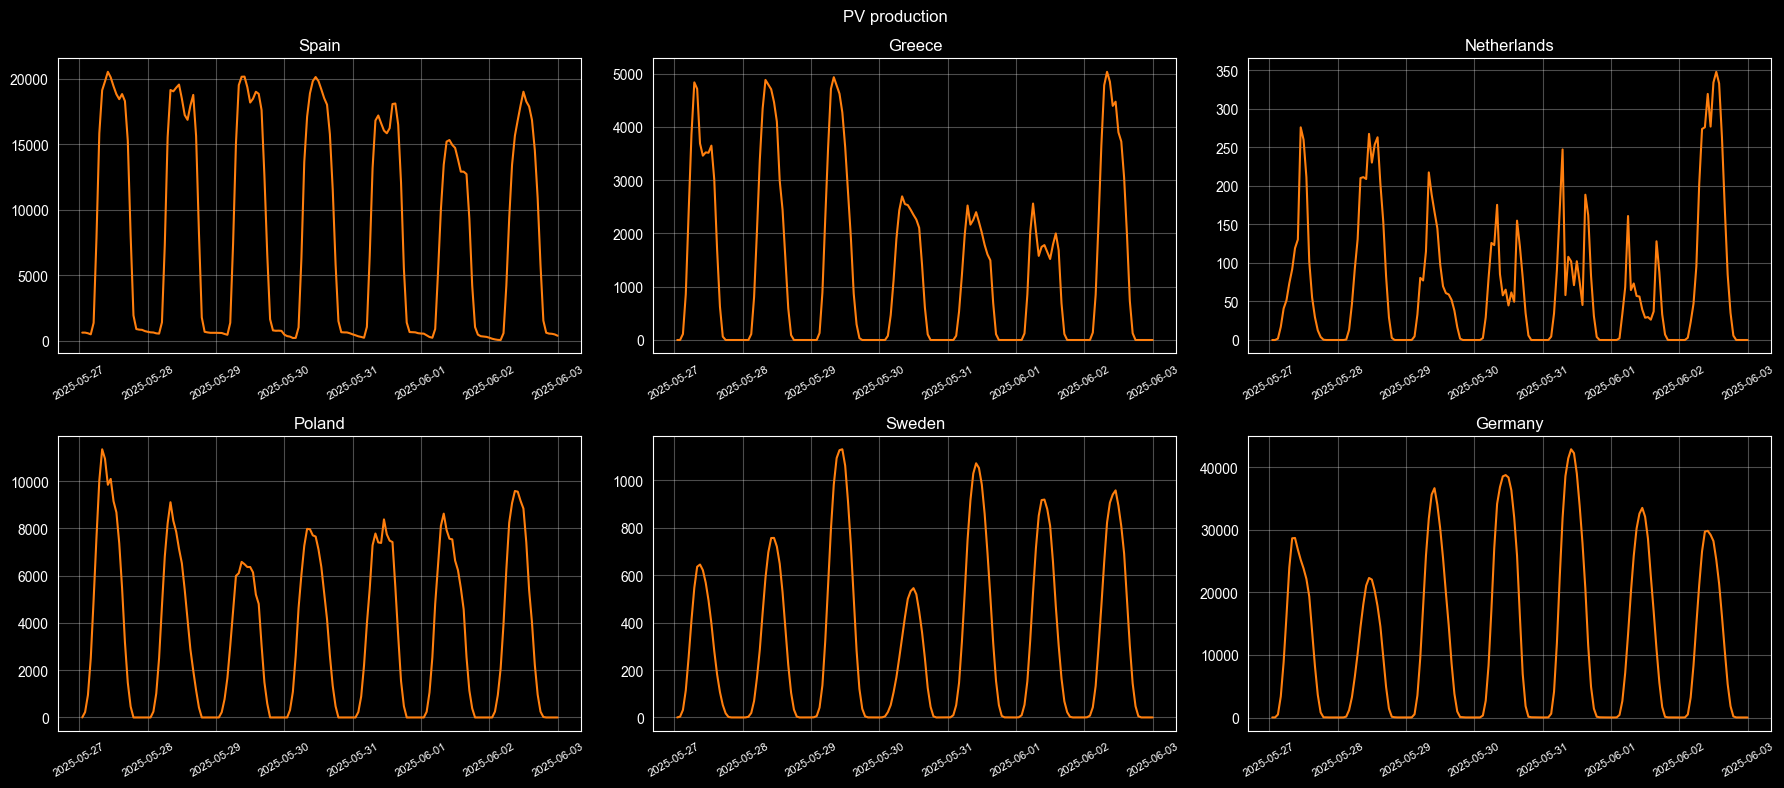

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()
for i, c in enumerate(COUNTRIES):
    df = data[c]
    val_end = int(len(df) * 0.85)
    week = df.iloc[val_end:val_end + 24 * 7]
    axes[i].plot(week["datetime"], week["solar_generation_MW"], color="tab:orange")
    axes[i].set_title(c.capitalize())
    axes[i].tick_params(axis="x", rotation=30, labelsize=8)
    axes[i].grid(alpha=0.3)
plt.suptitle("PV production")
plt.tight_layout()
plt.savefig("../results/eda/pv_weekly_pattern.png", dpi=150)
plt.show()

## 4. Autocorrelation на цената

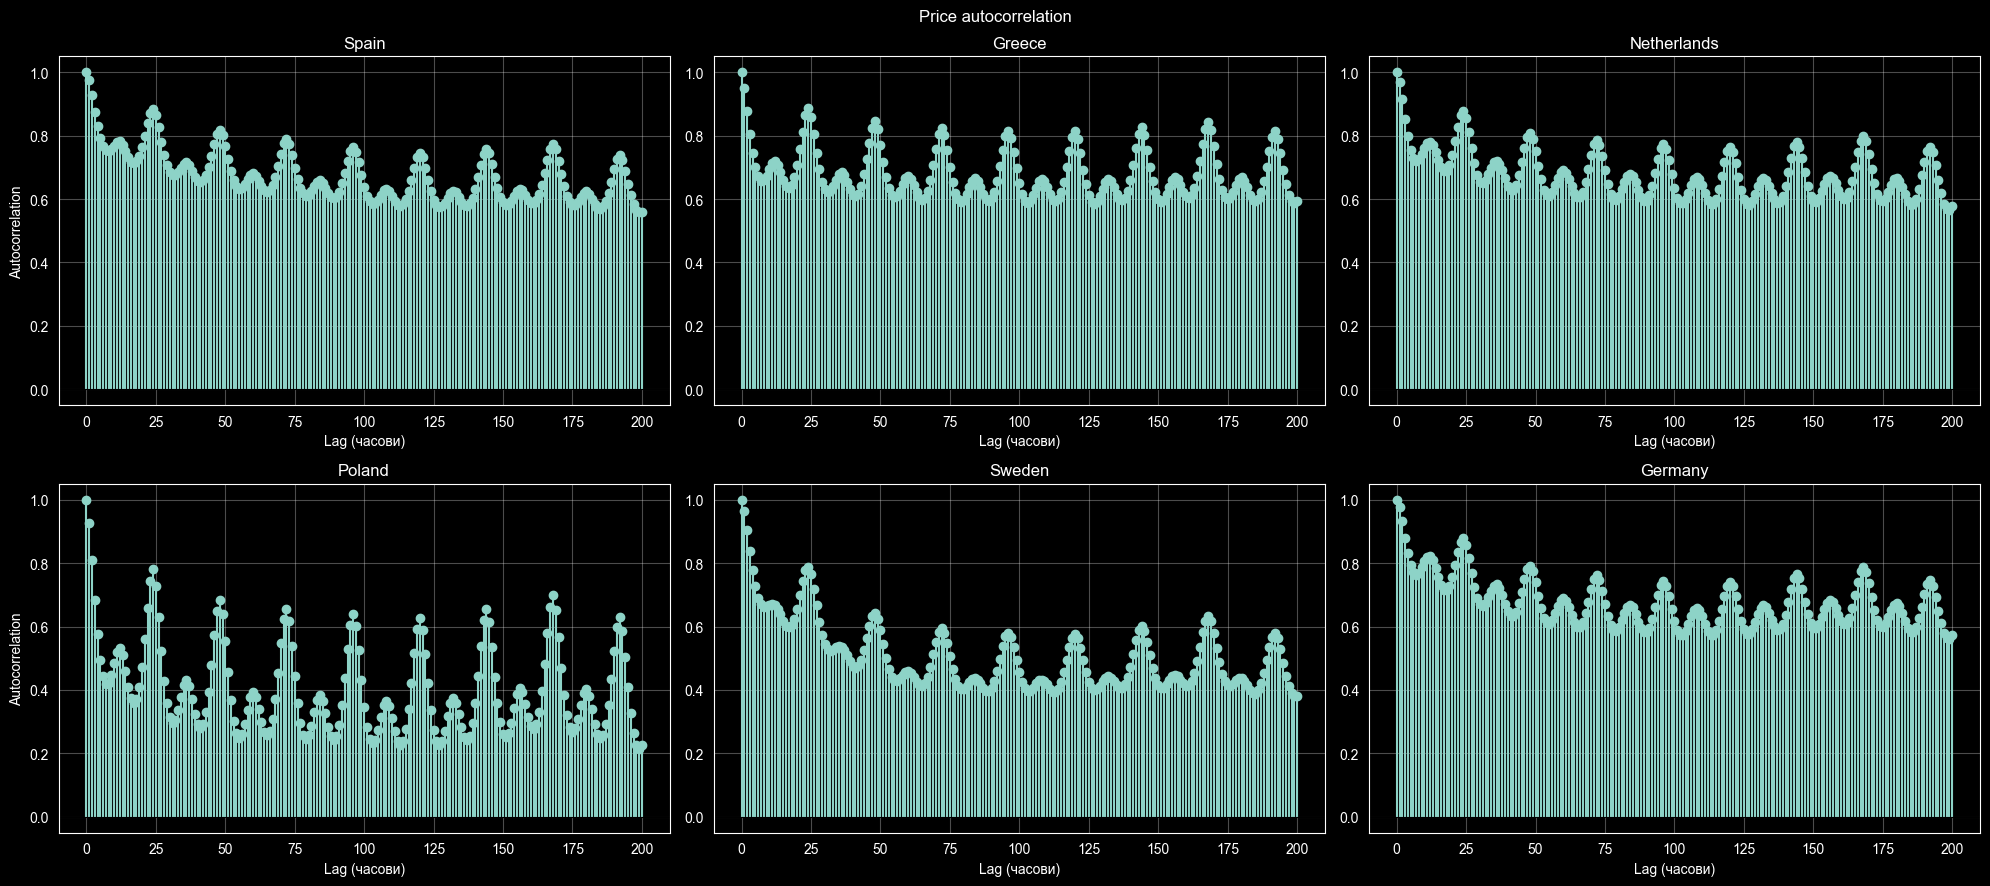

In [14]:
def compute_acf(series, n_lags):
    values = series.values
    mean = values.mean()
    denom = np.sum((values - mean) ** 2)
    return [np.sum((values[:len(values)-lag] - mean) * (values[lag:] - mean)) / denom for lag in range(n_lags + 1)]

n_lags = 200
fig, axes = plt.subplots(2, 3, figsize=(20, 9))
axes = axes.flatten()
for i, c in enumerate(COUNTRIES):
    acf = compute_acf(data[c]["Price (EUR/MWhe)"], n_lags)
    axes[i].stem(range(n_lags + 1), acf, basefmt=" ")
    axes[i].axhline(0, color="black", linewidth=0.8)
    axes[i].set_title(c.capitalize())
    axes[i].set_xlabel("Lag (часови)")
    if i % 3 == 0:
        axes[i].set_ylabel("Autocorrelation")
    axes[i].grid(alpha=0.3)
plt.suptitle("Price autocorrelation")
plt.tight_layout()
plt.savefig("../results/eda/price_autocorrelation.png", dpi=150)
plt.show()

## 5. Корелација помеѓу временски услови и производство

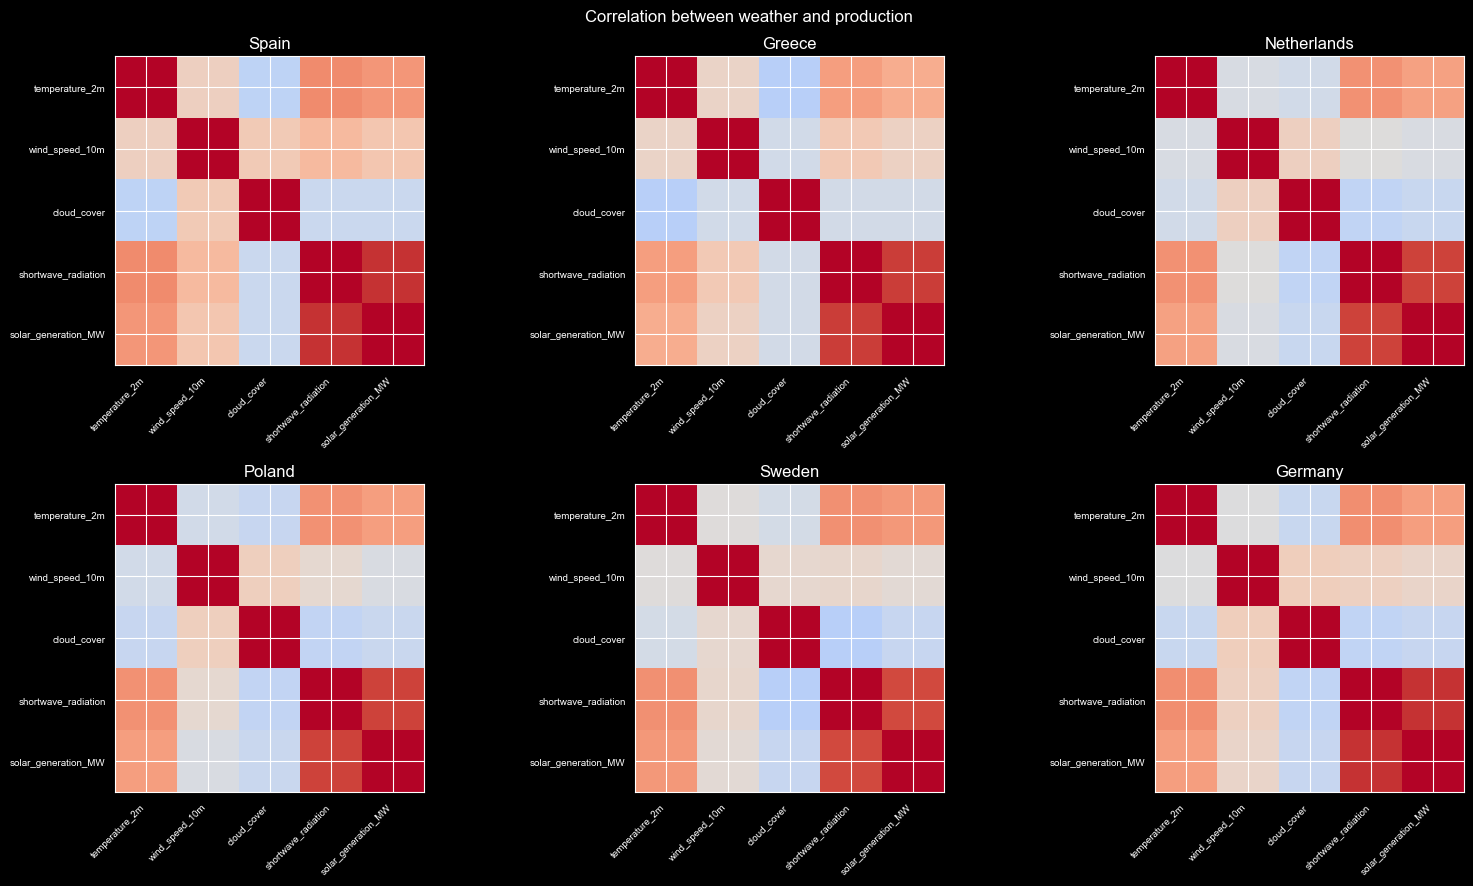

In [15]:
weather_cols = ["temperature_2m", "wind_speed_10m", "cloud_cover", "shortwave_radiation", "solar_generation_MW"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, c in enumerate(COUNTRIES):
    corr = data[c][weather_cols].corr()
    im = axes[i].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    axes[i].set_xticks(range(len(weather_cols)))
    axes[i].set_yticks(range(len(weather_cols)))
    axes[i].set_xticklabels(weather_cols, rotation=45, ha="right", fontsize=7)
    axes[i].set_yticklabels(weather_cols, fontsize=7)
    axes[i].set_title(c.capitalize())
plt.suptitle("Correlation between weather and production")
plt.tight_layout()
plt.savefig("../results/eda/weather_correlation.png", dpi=150)
plt.show()